# 🌳 Drzewa decyzyjne – od prostych ifów do uczenia maszynowego

---

## Cel lekcji

Poznamy:
- czym jest drzewo decyzyjne,
- jak można je zapisać za pomocą instrukcji `if`,
- jak drzewo decyzyjne wygląda graficznie

## 1️⃣ Prosty przykład – czy iść na spacer?

Reguły:
- Jeśli pada → nie idziemy
- Jeśli nie pada:
    - Jeśli świeci słońce → idziemy
    - W przeciwnym razie → nie idziemy

In [10]:
def czy_isc_na_spacer(slonecznie, pada):
    if pada:
        return "Nie idziemy"
    else:
        if slonecznie:
            return "Idziemy"
        else:
            return "Nie idziemy"

print(czy_isc_na_spacer(True, False))

Idziemy


## 2️⃣ Drzewo jako schemat

```
            [Czy pada?]
             /        \
          TAK          NIE
          /              \
  Nie idziemy     [Czy świeci słońce?]
                    /          \
                  TAK           NIE
                  /              \
               Idziemy        Nie idziemy
```

# 🟢 Część praktyczna – dane na płaszczyźnie

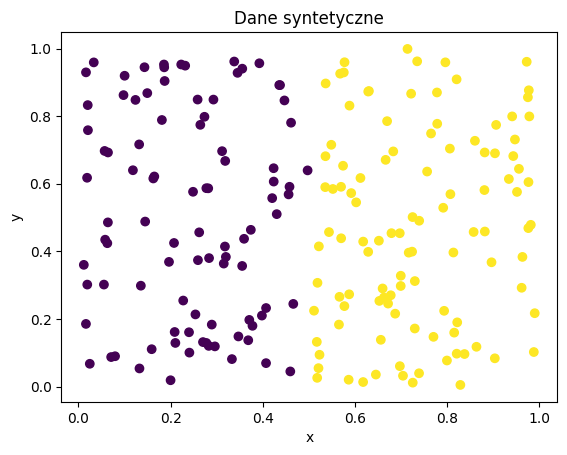

In [11]:
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(0)
X = np.random.rand(200, 2)
y = (X[:, 0] > 0.5).astype(int)

plt.scatter(X[:, 0], X[:, 1], c=y)
plt.title("Dane syntetyczne")
plt.xlabel("x")
plt.ylabel("y")
plt.show()

## Funkcja drukująca klasyfikator

In [12]:
def plot_decision_boundary(clf, X, y, title):
    x_min, x_max = X[:, 0].min() - 0.1, X[:, 0].max() + 0.1
    y_min, y_max = X[:, 1].min() - 0.1, X[:, 1].max() + 0.1
    xx, yy = np.meshgrid(np.linspace(x_min, x_max, 300),
                         np.linspace(y_min, y_max, 300))

    Z = np.array([clf(x) for x in np.c_[xx.ravel(), yy.ravel()]])
    Z = Z.reshape(xx.shape)

    plt.contourf(xx, yy, Z, alpha=0.3)
    plt.scatter(X[:, 0], X[:, 1], c=y, edgecolor='k')
    plt.title(title)
    plt.show()

## 3️⃣ Proste drzewo – jedno rozcięcie

Skuteczność: 0.705


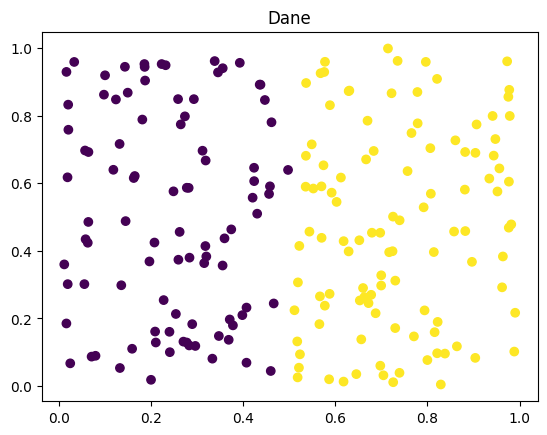

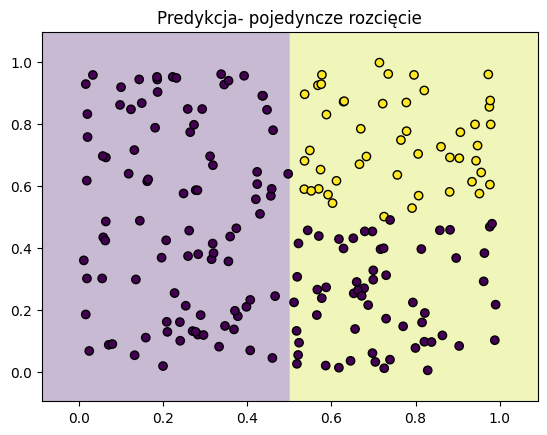

In [16]:
def klasyfikator_1(x):
    if x[0] > 0.5:
        return 1
    else:
        return 0

pred = np.array([klasyfikator_1(x) for x in X])
print("Skuteczność:", np.mean(pred == y))

plt.scatter(X[:, 0], X[:, 1], c=pred)
plt.title("Dane")
plt.show()

plot_decision_boundary(klasyfikator_1, X, y, "Predykcja- pojedyncze rozcięcie")

## 4️⃣ Bardziej złożone drzewo

Skuteczność: 1.0


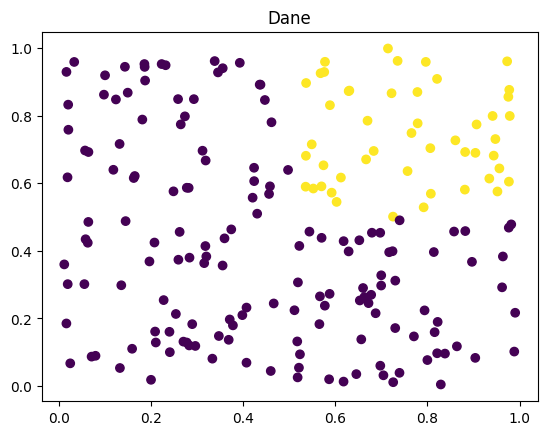

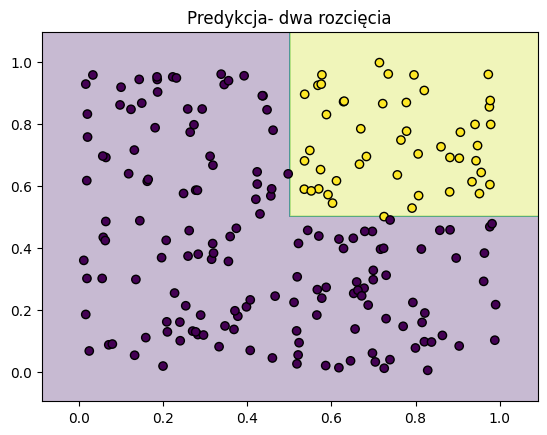

In [15]:
y = ((X[:, 0] > 0.5) & (X[:, 1] > 0.5)).astype(int)

def klasyfikator_2(x):
    if x[0] > 0.5:
        if x[1] > 0.5:
            return 1
        else:
            return 0
    else:
        return 0

pred = np.array([klasyfikator_2(x) for x in X])
print("Skuteczność:", np.mean(pred == y))

plt.scatter(X[:, 0], X[:, 1], c=pred)
plt.title("Dane")
plt.show()
plot_decision_boundary(klasyfikator_2, X, y, "Predykcja- dwa rozcięcia")